In [45]:
# ============================================================
# FINAL PROJECT — PREDICTIVE ANALYTICS IN BANKING
# PT Bank Sentral Merakyat (BSM) — Prediksi Deposito Berjangka
# ============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from matplotlib.ticker import FuncFormatter

# Statistics
from scipy.stats import chi2_contingency, ttest_ind, f_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Display Config
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
RANDOM_STATE = 42

print("Libraries berhasil diimport")
print(f"Pandas version : {pd.__version__}")
print(f"NumPy version  : {np.__version__}")

Libraries berhasil diimport
Pandas version : 3.0.2
NumPy version  : 2.4.4


# 🏦 PREDICTIVE ANALYTICS IN BANKING
## Prediksi Keberhasilan Kampanye Deposito Berjangka
### PT Bank Sentral Merakyat (BSM) — Divisi Data Science & Analytics

## A. BUSINESS UNDERSTANDING

### A.1 Background & Context

Pasca-pandemi COVID-19, PT Bank Sentral Merakyat (BSM) menghadapi tekanan ganda pada lini bisnis deposito berjangka.

Pada periode **2020–2021**, Bank Indonesia menurunkan suku bunga acuan (BI Rate) ke level terendah historis — 3,5% — untuk mendorong pemulihan ekonomi. Dampaknya: imbal hasil deposito tidak kompetitif dibandingkan instrumen lain seperti reksa dana pasar uang, Obligasi Ritel Indonesia (ORI), atau Sukuk Tabungan. Dana Pihak Ketiga (DPK) BSM pada segmen deposito berjangka mengalami stagnasi.

Memasuki **2022–2023**, Bank Indonesia memulai siklus pengetatan moneter secara agresif untuk meredam inflasi pasca-pandemi — BI Rate naik bertahap hingga menyentuh 6,0%. Kenaikan ini membuat deposito berjangka kembali menjadi instrumen investasi yang menarik bagi masyarakat.

BSM merespons peluang ini dengan meluncurkan **kampanye telemarketing** yang menargetkan:
1. Nasabah existing yang sebelumnya mengalihkan dana ke instrumen lain
2. Segmen prospek baru yang belum pernah berinvestasi di BSM

Tim Data Science BSM ditugaskan untuk membangun **model prediktif** yang mampu mengidentifikasi nasabah mana yang paling berpotensi menerima tawaran deposito berjangka — sehingga kampanye telemarketing dapat dijalankan lebih efisien dan tepat sasaran.

**Stakeholder utama:**
- **Chief Marketing Officer (CMO):** Butuh model untuk mengoptimalkan alokasi sumber daya call center
- **Tim Telemarketing:** Butuh daftar prioritas nasabah yang berpotensi tinggi
- **Tim Keuangan:** Butuh estimasi konversi untuk proyeksi DPK
- **Chief Risk Officer (CRO):** Butuh memastikan strategi tidak melanggar regulasi OJK terkait penjualan produk investasi

### A.2 Problem Statement

Berdasarkan konteks di atas, masalah yang dihadapi BSM dapat dirumuskan sebagai:

> **"Bagaimana memprediksi apakah seorang nasabah akan setuju membuka deposito berjangka di BSM melalui kampanye telemarketing, sehingga Tim Telemarketing dapat memprioritaskan kontak kepada nasabah dengan potensi konversi tertinggi?"**

Ini adalah masalah **klasifikasi biner**:
- **Kelas 1 (Subscribe = Yes):** Nasabah setuju membuka deposito berjangka
- **Kelas 0 (Subscribe = No):** Nasabah menolak tawaran

Tanpa model prediktif, Tim Telemarketing harus menghubungi semua nasabah secara acak — biaya tinggi, konversi rendah, dan banyak waktu agen yang terbuang.

### A.3 Cost of Errors — Mengapa FP dan FN Penting?

Dalam konteks kampanye telemarketing BSM, setiap kesalahan prediksi memiliki **dampak finansial yang asimetris**:

| Tipe | Prediksi | Realita | Skenario | Biaya |
|------|---------|---------|----------|-------|
| **True Positive (TP)** | Subscribe | Subscribe | Call relevan, nasabah berhasil dikonversi | Rp 50.000 (biaya 1 call) |
| **True Negative (TN)** | Tidak | Tidak | Nasabah tidak dihubungi, tidak ada biaya tambahan | Rp 0 |
| **False Positive (FP)** | Subscribe | Tidak | Call sia-sia, tidak ada konversi — waktu & biaya agen terbuang | Rp 50.000 |
| **False Negative (FN)** | Tidak | Subscribe | **Nasabah berharga terlewat, BSM kehilangan potensi margin deposito** | **Rp 500.000** |

#### Mengapa False Negative (FN) Jauh Lebih Fatal?

**Biaya per call (FP = Rp 50.000)** dihitung dari:
- Gaji telemarketer bank Indonesia: Rp 3.500.000–5.000.000/bulan
- Kapasitas: ~200 panggilan/bulan (10 call/hari × 20 hari kerja)
- Biaya gaji per call: Rp 17.500–25.000
- Ditambah overhead (VoIP, CRM, training, supervisor): ~100%
- **Total: ~Rp 35.000–50.000 per call** → digunakan Rp 50.000 (konservatif)

**Kehilangan per nasabah (FN = Rp 500.000)** dihitung dari:
- NIM (Net Interest Margin) rata-rata bank Indonesia: 4–5% per tahun (data OJK 2022)
- Rata-rata nominal deposito nasabah ritel BSM: ~Rp 50.000.000
- Gross spread: Rp 50 juta × 4% = Rp 2.000.000/tahun
- Setelah biaya operasional (~75% BOPO): **profit bersih ~Rp 500.000/nasabah/tahun**
- Belum termasuk: nilai cross-selling (KPR, kartu kredit), loyalitas jangka panjang

**Rasio biaya FN:FP = 10:1** → artinya setiap satu nasabah potensial yang terlewat setara kerugian 10 call sia-sia.

#### Kesimpulan: Minimasi False Negative adalah Prioritas Utama BSM.
Kita lebih baik *terlalu waspada* (menghubungi nasabah yang ternyata tidak mau) daripada *melewatkan* nasabah yang sebenarnya mau bergabung.

### A.4 Goals

**Goals Bisnis:**
1. Memprediksi nasabah yang berpotensi membuka deposito berjangka, sehingga Tim Telemarketing dapat fokus pada segmen berkonversi tinggi
2. Mengidentifikasi karakteristik demografis dan finansial "nasabah ideal" untuk deposito BSM
3. Mengoptimalkan biaya kampanye telemarketing dengan mengurangi call sia-sia (False Positive)
4. Memberikan rekomendasi strategis berbasis data: segmen mana yang diprioritaskan, timing terbaik, dan pendekatan yang efektif

**Goals Teknis:**
1. Membangun pipeline ML yang menghindari data leakage (stratified split, scaling dalam pipeline)
2. Menangani class imbalance (~89:11) dengan eksperimen resampling sistematis
3. Mengidentifikasi fitur-fitur dominan yang memengaruhi keputusan subscribe
4. Membangun model dengan F2-Score setinggi mungkin pada data test
5. Menentukan threshold optimal: F2-optimal (evaluasi model) dan Profit-optimal (deployment)
6. Menghitung simulasi ROI dalam Rupiah untuk memvalidasi nilai bisnis model

### A.5 Analytic Approach

Proyek ini menggunakan pendekatan **hybrid: Analytics + Machine Learning**:

**Analytics (Descriptive + Inferential):**
- Exploratory Data Analysis (EDA) mendalam dengan framework 5W-1H
- Uji signifikansi statistik formal (Chi-Square untuk kategorikal, T-test/ANOVA untuk numerikal)
- Segmentasi nasabah berbasis temuan EDA

**Machine Learning (Predictive):**
- Benchmarking sistematis: 6 algoritma × 5 strategi resampling = 30 kombinasi
- Hyperparameter tuning pada kombinasi terbaik
- Dual-threshold optimization: F2-optimal dan Profit-optimal (dalam Rupiah)

**Catatan penting — Duration Paradox:**
Kolom `duration` (durasi panggilan terakhir dalam detik) **mengandung data leakage**: nilainya hanya bisa diketahui *setelah* panggilan selesai, bukan *sebelum*. Oleh karena itu:
- `duration` **DIGUNAKAN** di bagian Analytics/EDA untuk mendapatkan insight
- `duration` **DIHAPUS** sebelum memasuki bagian Machine Learning

### A.6 Evaluation Metrics

**Metrik Utama: F2-Score**

$$F_2 = 5 \cdot \frac{\text{Precision} \times \text{Recall}}{4 \times \text{Precision} + \text{Recall}}$$

Dengan beta = 2, F2-Score memberikan **bobot 2× lebih besar pada Recall** dibandingkan Precision.

**Mengapa F2, bukan metrik lain?**

| Metrik | Masalah dalam Konteks BSM |
|--------|--------------------------|
| Accuracy | Misleading pada data imbalanced. Model yang selalu prediksi "tidak" punya akurasi 89% tapi tidak berguna |
| Recall murni | Recall 100% tercapai dengan prediksi "semua subscribe" → 41.000+ call sia-sia, ROI negatif |
| F1-Score | Bobot sama untuk FP dan FN, padahal FN 10× lebih mahal dari FP |
| **F2-Score** | ✅ Prioritaskan Recall (minimasi FN), tapi Precision tetap dijaga agar ROI positif |

**Metrik Pendukung:**

| Metrik | Fungsi |
|--------|--------|
| Recall | Berapa % nasabah yang mau terdeteksi — prioritas utama BSM |
| ROC-AUC | Kemampuan diskriminasi model secara keseluruhan |
| Precision | Monitoring agar call center tidak overload dengan false alarms |
| **Savings (Rp)** | **Metrik bisnis final: penghematan vs tanpa model** |
| ROI (%) | Return on Investment dari implementasi model |

## B. DATA UNDERSTANDING

### B.1 Import Libraries
*(Library sudah diimport pada cell pertama di atas)*

In [46]:
# ─────────────────────────────────────────────────────────────
# B.2 Load Dataset + Fix Macro Indicator Columns
# ─────────────────────────────────────────────────────────────

# Load dataset
df = pd.read_csv('bank-additional-full.csv', sep=';')

print("=" * 60)
print("DATASET BERHASIL DIMUAT")
print("=" * 60)
print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]}")
print(f"\n5 Baris Pertama:")
display(df.head())
print(f"\n5 Baris Terakhir:")
display(df.tail())

DATASET BERHASIL DIMUAT
Jumlah baris  : 41,188
Jumlah kolom  : 21

5 Baris Pertama:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no



5 Baris Terakhir:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,239,3,999,1,failure,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",no


In [47]:
# ─────────────────────────────────────────────────────────────
# FIX: Kolom Macro Indicator tersimpan sebagai object
# karena menggunakan koma sebagai pemisah desimal (format Eropa)
# Action : Ganti koma → titik, lalu konversi ke float
# Why    : Kolom-kolom ini adalah fitur numerik yang krusial
#          (JIBOR, IHK, IKK, dll). Jika dibiarkan sebagai object,
#          model tidak bisa membacanya sebagai angka.
# Business Impact: Macro indicators adalah konteks ekonomi yang
#          menjelaskan MENGAPA nasabah mau/tidak mau deposito.
# ─────────────────────────────────────────────────────────────

macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']

print("Tipe data SEBELUM fix:")
print(df[macro_cols].dtypes.to_string())
print()

for col in macro_cols:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

print("Tipe data SESUDAH fix:")
print(df[macro_cols].dtypes.to_string())
print()
print("Sample nilai setelah fix:")
display(df[macro_cols].head(3))

Tipe data SEBELUM fix:
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
nr.employed       float64

Tipe data SESUDAH fix:
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
nr.employed       float64

Sample nilai setelah fix:


,emp.var.rate,cons.price.idx,cons.conf.idx,nr.employed
0,1.1000,93.9940,-36.4000,"5,191.0000"
1,1.1000,93.9940,-36.4000,"5,191.0000"
2,1.1000,93.9940,-36.4000,"5,191.0000"


In [48]:
# ─────────────────────────────────────────────────────────────
# B.3 Dataset Overview — Info, Describe, Deskripsi Kolom
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("INFORMASI TIPE DATA & NON-NULL COUNT")
print("=" * 60)
df.info()

INFORMASI TIPE DATA & NON-NULL COUNT
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.

In [49]:
print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF — FITUR NUMERIK")
print("=" * 60)
display(df.describe())


STATISTIK DESKRIPTIF — FITUR NUMERIK


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,"41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000"
mean,40.0241,258.2850,2.5676,962.4755,0.1730,0.0819,93.5757,-40.5026,3.6213,"5,167.0359"
std,10.4212,259.2792,2.7700,186.9109,0.4949,1.5710,0.5788,4.6282,1.7344,72.2515
min,17.0000,0.0000,1.0000,0.0000,0.0000,-3.4000,92.2010,-50.8000,0.6340,"4,963.6000"
25%,32.0000,102.0000,1.0000,999.0000,0.0000,-1.8000,93.0750,-42.7000,1.3440,"5,099.1000"
50%,38.0000,180.0000,2.0000,999.0000,0.0000,1.1000,93.7490,-41.8000,4.8570,"5,191.0000"
75%,47.0000,319.0000,3.0000,999.0000,0.0000,1.4000,93.9940,-36.4000,4.9610,"5,228.1000"
max,98.0000,"4,918.0000",56.0000,999.0000,7.0000,1.4000,94.7670,-26.9000,5.0450,"5,228.1000"


In [50]:
print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF — FITUR KATEGORIKAL")
print("=" * 60)
display(df.describe(include='object'))


STATISTIK DESKRIPTIF — FITUR KATEGORIKAL


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


#### Deskripsi Variabel Dataset

**Demografi & Profil Nasabah:**
| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `age` | Numerik | Usia nasabah (tahun) |
| `job` | Kategorikal | Kategori pekerjaan (admin, blue-collar, entrepreneur, dll) |
| `marital` | Kategorikal | Status pernikahan (single, married, divorced) |
| `education` | Kategorikal | Tingkat pendidikan (ordinal: illiterate → university.degree) |
| `default` | Kategorikal | Riwayat kredit macet? (yes, no, unknown) |
| `housing` | Kategorikal | Punya pinjaman KPR? (yes, no, unknown) |
| `loan` | Kategorikal | Punya pinjaman pribadi? (yes, no, unknown) |

**Kampanye Saat Ini:**
| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `contact` | Kategorikal | Jenis kontak (cellular / telephone) |
| `month` | Kategorikal | Bulan terakhir dihubungi |
| `day_of_week` | Kategorikal | Hari terakhir dihubungi |
| `duration` | Numerik | ⚠️ Durasi call terakhir (detik) — **HANYA untuk EDA, tidak masuk model** |
| `campaign` | Numerik | Jumlah kontak dalam kampanye ini |

**Riwayat Kampanye Sebelumnya:**
| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `pdays` | Numerik | Hari sejak kontak kampanye sebelumnya (999 = belum pernah) |
| `previous` | Numerik | Jumlah kontak sebelum kampanye ini |
| `poutcome` | Kategorikal | Hasil kampanye sebelumnya (success, failure, nonexistent) |

**Macro Economic Indicators (Konteks BSM Indonesia):**
| Kolom | Tipe | Interpretasi untuk BSM |
|-------|------|----------------------|
| `emp.var.rate` | Numerik | Pertumbuhan Ketenagakerjaan YoY (Sakernas BPS) |
| `cons.price.idx` | Numerik | Indeks Harga Konsumen / IHK (BPS) |
| `cons.conf.idx` | Numerik | Indeks Keyakinan Konsumen / IKK (Survei BI) |
| `euribor3m` | Numerik | JIBOR 3 Bulan / Proksi BI Rate |
| `nr.employed` | Numerik | Jumlah Angkatan Kerja Aktif (juta orang, BPS) |

**Target Variable:**
| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `y` | Kategorikal | Setuju membuka deposito berjangka? (yes / no) |

In [51]:
# ─────────────────────────────────────────────────────────────
# B.4 Missing Values Analysis
#
# PENTING: Dataset ini menggunakan string "unknown" sebagai
# representasi missing values — BUKAN NaN/null!
# df.isnull().sum() akan mengembalikan 0 untuk semua kolom
# padahal ada missing values yang tersembunyi.
#
# Langkah: Deteksi "unknown" terlebih dahulu sebelum
# menggantinya dengan NaN untuk analisis missingno.
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("CEK MISSING VALUES EKSPLISIT (NaN/null)")
print("=" * 60)
explicit_missing = df.isnull().sum()
if explicit_missing.sum() == 0:
    print("Tidak ada NaN/null eksplisit dalam dataset.")
    print(" TAPI perlu dicek: missing values mungkin direpresentasikan")
    print("    sebagai string 'unknown'!")
else:
    print(explicit_missing[explicit_missing > 0])

CEK MISSING VALUES EKSPLISIT (NaN/null)
Tidak ada NaN/null eksplisit dalam dataset.
 TAPI perlu dicek: missing values mungkin direpresentasikan
    sebagai string 'unknown'!


In [52]:
# Deteksi "unknown" per kolom
print("\n" + "=" * 60)
print("DETEKSI 'unknown' SEBAGAI MISSING VALUES TERSEMBUNYI")
print("=" * 60)

unknown_summary = []
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    n_unknown = (df[col] == 'unknown').sum()
    pct_unknown = n_unknown / len(df) * 100
    if n_unknown > 0:
        unknown_summary.append({
            'Kolom': col,
            'Jumlah Unknown': n_unknown,
            'Persentase (%)': round(pct_unknown, 2)
        })

if unknown_summary:
    unknown_df = pd.DataFrame(unknown_summary).sort_values('Persentase (%)', ascending=False)
    print(unknown_df.to_string(index=False))
    print(f"\nTotal kolom dengan 'unknown': {len(unknown_df)}")
else:
    print("Tidak ada nilai 'unknown' ditemukan.")


DETEKSI 'unknown' SEBAGAI MISSING VALUES TERSEMBUNYI
    Kolom  Jumlah Unknown  Persentase (%)
  default            8597         20.8700
education            1731          4.2000
  housing             990          2.4000
     loan             990          2.4000
      job             330          0.8000
  marital              80          0.1900

Total kolom dengan 'unknown': 6


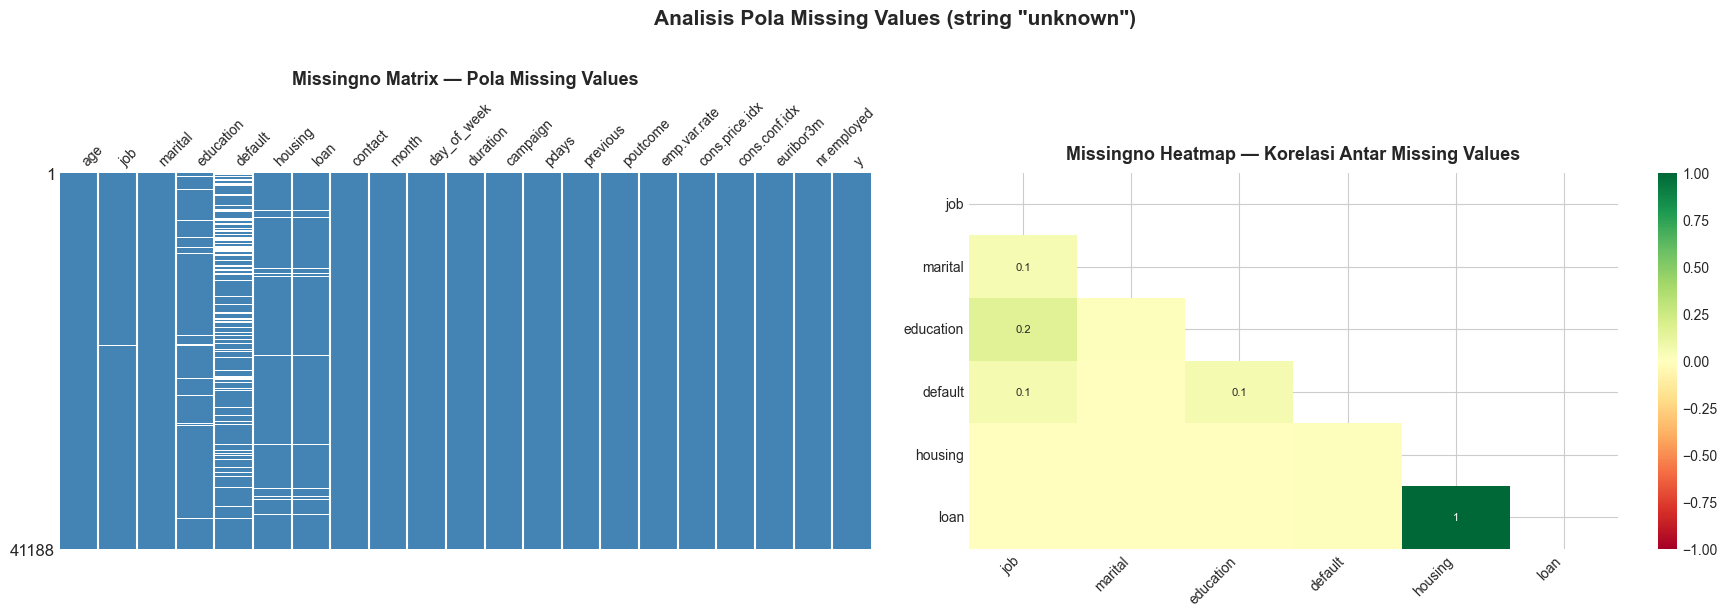

Plot disimpan sebagai 'missing_values_analysis.png'


In [53]:
# Missingno Analysis — ganti "unknown" ke NaN sementara untuk visualisasi
df_for_msno = df.copy()
df_for_msno.replace('unknown', np.nan, inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Matrix
msno.matrix(df_for_msno, ax=axes[0], sparkline=False, fontsize=10,
            color=(0.27, 0.52, 0.71))
axes[0].set_title('Missingno Matrix — Pola Missing Values', 
                   fontsize=13, fontweight='bold', pad=10)

# Heatmap
msno.heatmap(df_for_msno, ax=axes[1], fontsize=10, cmap='RdYlGn')
axes[1].set_title('Missingno Heatmap — Korelasi Antar Missing Values', 
                   fontsize=13, fontweight='bold', pad=10)

plt.suptitle('Analisis Pola Missing Values (string "unknown")', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('missing_values_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

del df_for_msno
print("Plot disimpan sebagai 'missing_values_analysis.png'")

<Figure size 1000x500 with 0 Axes>

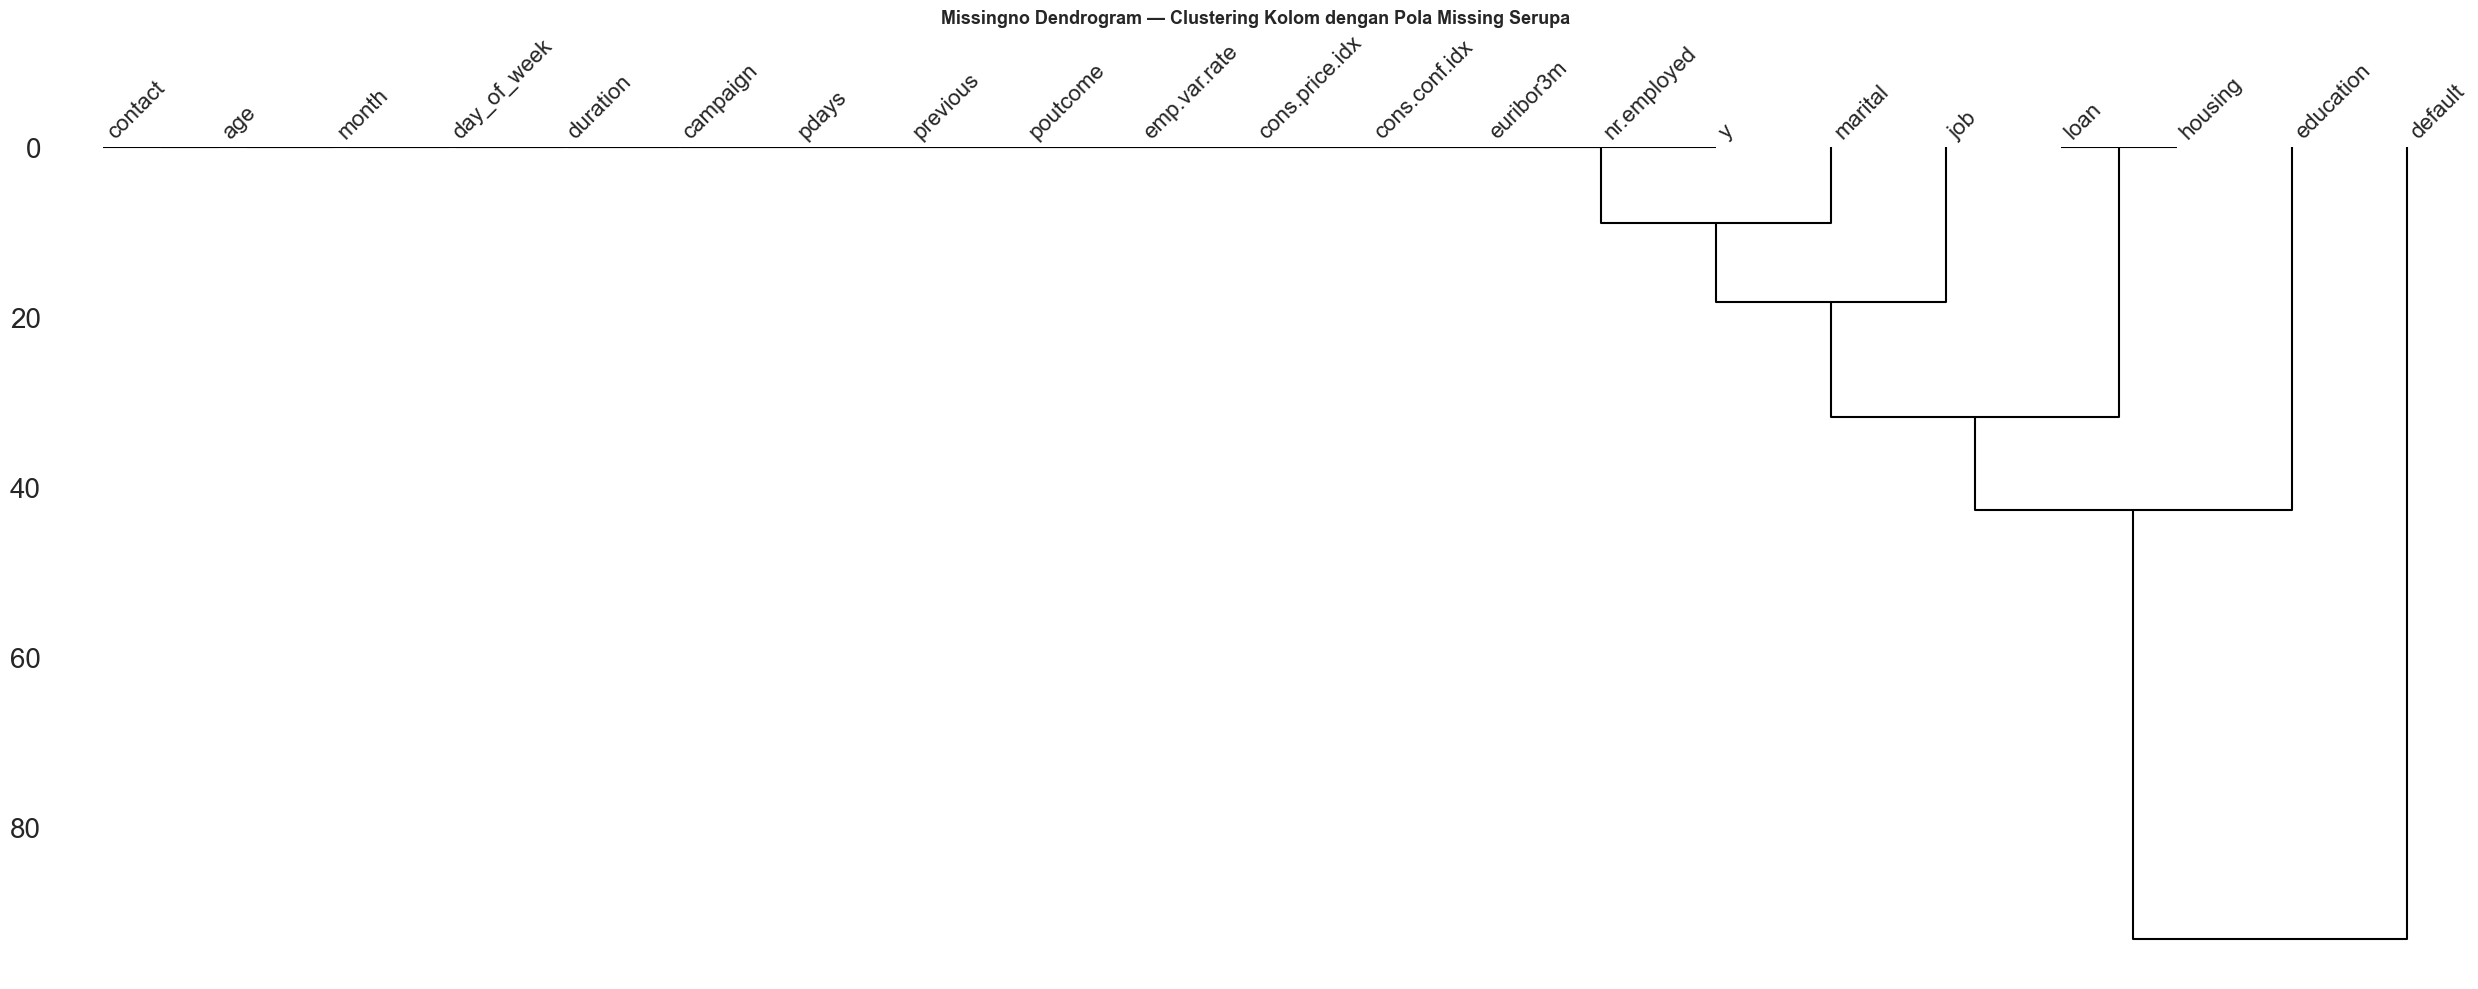

Plot disimpan sebagai 'missing_dendrogram.png'


In [54]:
# Dendrogram — clustering pola missing
df_for_dendro = df.copy()
df_for_dendro.replace('unknown', np.nan, inplace=True)

plt.figure(figsize=(10, 5))
msno.dendrogram(df_for_dendro)
plt.title('Missingno Dendrogram — Clustering Kolom dengan Pola Missing Serupa',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('missing_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

del df_for_dendro
print("Plot disimpan sebagai 'missing_dendrogram.png'")

In [55]:
# ─────────────────────────────────────────────────────────────
# B.5 Duplicate Check
# ─────────────────────────────────────────────────────────────

dup_count = df.duplicated().sum()
print("=" * 60)
print("CEK DATA DUPLIKAT")
print("=" * 60)
print(f"Jumlah baris duplikat : {dup_count:,}")
print(f"Persentase duplikat   : {dup_count/len(df)*100:.2f}%")

if dup_count > 0:
    print("\nContoh baris duplikat (5 pertama):")
    display(df[df.duplicated(keep=False)].head())
else:
    print("\nTidak ada data duplikat.")

CEK DATA DUPLIKAT
Jumlah baris duplikat : 12
Persentase duplikat   : 0.03%

Contoh baris duplikat (5 pertama):


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,124,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8550,"5,191.0000",no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,124,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8550,"5,191.0000",no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4000,93.9180,-42.7000,4.9660,"5,228.1000",no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4000,93.9180,-42.7000,4.9660,"5,228.1000",no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4000,93.9180,-42.7000,4.9620,"5,228.1000",no


In [56]:
# ─────────────────────────────────────────────────────────────
# B.6 Distribusi Target Variable (Class Imbalance Check)
# ─────────────────────────────────────────────────────────────

target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

print("=" * 60)
print("DISTRIBUSI TARGET VARIABLE (y: subscribe deposito?)")
print("=" * 60)
for label in target_counts.index:
    bar = "█" * int(target_pct[label])
    print(f"  {label:>3} : {target_counts[label]:,} ({target_pct[label]:.2f}%) {bar}")

ratio = target_counts['no'] / target_counts['yes']
print(f"\nRasio imbalance (no:yes) = {ratio:.1f}:1")
print(f"\nDataset menunjukkan CLASS IMBALANCE.")
print(f"  Teknik resampling WAJIB digunakan dalam tahap pemodelan.")

DISTRIBUSI TARGET VARIABLE (y: subscribe deposito?)
   no : 36,548 (88.73%) ████████████████████████████████████████████████████████████████████████████████████████
  yes : 4,640 (11.27%) ███████████

Rasio imbalance (no:yes) = 7.9:1

Dataset menunjukkan CLASS IMBALANCE.
  Teknik resampling WAJIB digunakan dalam tahap pemodelan.


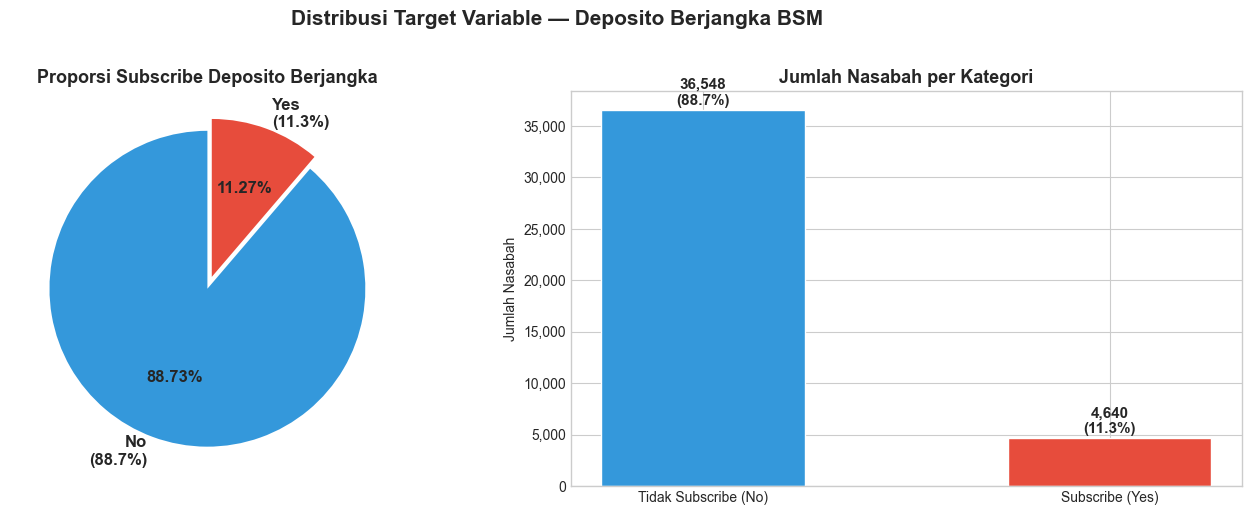

Plot disimpan sebagai 'target_distribution.png'


In [57]:
# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#3498db', '#e74c3c']
explode = (0, 0.08)
axes[0].pie(
    target_counts.values,
    labels=[f'No\n({target_pct["no"]:.1f}%)', f'Yes\n({target_pct["yes"]:.1f}%)'],
    colors=colors,
    explode=explode,
    autopct='%1.2f%%',
    startangle=90,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
axes[0].set_title('Proporsi Subscribe Deposito Berjangka', 
                   fontsize=13, fontweight='bold')

# Bar chart
bars = axes[1].bar(
    ['Tidak Subscribe (No)', 'Subscribe (Yes)'],
    target_counts.values,
    color=colors,
    edgecolor='white',
    width=0.5
)
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2.,
        bar.get_height() + 200,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontweight='bold', fontsize=11
    )
axes[1].set_title('Jumlah Nasabah per Kategori', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Nasabah')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distribusi Target Variable — Deposito Berjangka BSM',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'target_distribution.png'")

In [58]:
# ─────────────────────────────────────────────────────────────
# B.7 Kesimpulan Data Understanding
# ─────────────────────────────────────────────────────────────

print(f"\nDIMENSI DATASET:")
print(f"   Baris  : {df.shape[0]:,}")
print(f"   Kolom  : {df.shape[1]}")

print(f"\nTIPE DATA:")
dtype_summary = df.dtypes.value_counts()
for dtype, count in dtype_summary.items():
    print(f"   {str(dtype):<12}: {count} kolom")

print(f"\nSTATUS KOLOM MACRO (setelah fix):")
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']
for col in macro_cols:
    print(f"   {col:<20}: {df[col].dtype}")

print(f"\nMISSING VALUES ('unknown'):")
cat_cols = df.select_dtypes(include='object').columns
any_unknown = False
for col in cat_cols:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f"   {col:<15}: {n:,} ({n/len(df)*100:.1f}%)")
        any_unknown = True
if not any_unknown:
    print("   Tidak ada 'unknown' ditemukan.")

print(f"\nDUPLIKAT:")
dup = df.duplicated().sum()
print(f"   {dup:,} baris duplikat ({dup/len(df)*100:.2f}%)")

print(f"\nTARGET VARIABLE (y):")
for label in df['y'].value_counts().index:
    cnt = df['y'].value_counts()[label]
    pct = df['y'].value_counts(normalize=True)[label] * 100
    print(f"   {label:>3}: {cnt:,} ({pct:.2f}%)")
ratio = df['y'].value_counts()['no'] / df['y'].value_counts()['yes']
print(f"   Rasio no:yes = {ratio:.1f}:1")

print(f"\nSTATISTIK NUMERIK RINGKAS:")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"   Jumlah fitur numerik: {len(num_cols)}")
print(f"   Kolom: {num_cols}")

print(f"\nCATATAN PENTING UNTUK PHASE 2:")
print(f"   1. {len([c for c in df.select_dtypes('object').columns if (df[c]=='unknown').sum()>0])} kolom memiliki 'unknown' yang perlu ditangani")
print(f"   2. Kolom 'duration' berpotensi data leakage → drop sebelum ML")
print(f"   3. Class imbalance rasio {ratio:.0f}:1 → wajib resampling")
print(f"   4. Lihat missingno plot untuk pola missing sebelum memutuskan imputasi")
print("=" * 70)


DIMENSI DATASET:
   Baris  : 41,188
   Kolom  : 21

TIPE DATA:
   str         : 11 kolom
   int64       : 5 kolom
   float64     : 5 kolom

STATUS KOLOM MACRO (setelah fix):
   emp.var.rate        : float64
   cons.price.idx      : float64
   cons.conf.idx       : float64
   nr.employed         : float64

MISSING VALUES ('unknown'):
   job            : 330 (0.8%)
   marital        : 80 (0.2%)
   education      : 1,731 (4.2%)
   default        : 8,597 (20.9%)
   housing        : 990 (2.4%)
   loan           : 990 (2.4%)

DUPLIKAT:
   12 baris duplikat (0.03%)

TARGET VARIABLE (y):
    no: 36,548 (88.73%)
   yes: 4,640 (11.27%)
   Rasio no:yes = 7.9:1

STATISTIK NUMERIK RINGKAS:
   Jumlah fitur numerik: 10
   Kolom: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

CATATAN PENTING UNTUK PHASE 2:
   1. 6 kolom memiliki 'unknown' yang perlu ditangani
   2. Kolom 'duration' berpotensi data leakage → drop seb